In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import cv2
import os
import matplotlib.pyplot as plt

In [3]:
dataset_path = "/content/drive/MyDrive/Image_Enhancement/dataset/our485/low"
output_path = "/content/drive/MyDrive/Image_Enhancement/output"

os.makedirs(output_path, exist_ok=True)

In [4]:
image_list = os.listdir(dataset_path)

print("Jumlah gambar :", len(image_list))
print(image_list[:10])

Jumlah gambar : 485
['100.png', '105.png', '104.png', '106.png', '101.png', '10.png', '107.png', '103.png', '102.png', '123.png']


MEMBACA DATASET DANKONVERSI BGR KE RGB

In [5]:
image_name = image_list[0]

image_path = os.path.join(dataset_path, image_name)

image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

KONVERSI BGR KE RGB

In [6]:
lab = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)

l, a, b = cv2.split(lab)

clahe = cv2.createCLAHE(
    clipLimit=2.0,
    tileGridSize=(8,8)
)

cl = clahe.apply(l)

enhanced_lab = cv2.merge((cl,a,b))

enhanced = cv2.cvtColor(
    enhanced_lab,
    cv2.COLOR_LAB2RGB
)

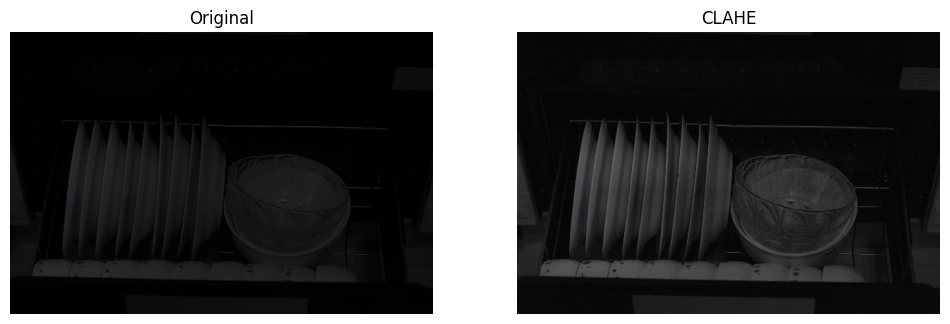

In [7]:
plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.imshow(image)
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(enhanced)
plt.title("CLAHE")
plt.axis("off")

plt.show()

In [8]:
save_path = os.path.join(output_path, image_name)

cv2.imwrite(
    save_path,
    cv2.cvtColor(enhanced, cv2.COLOR_RGB2BGR)
)

print("Berhasil disimpan di:")
print(save_path)

Berhasil disimpan di:
/content/drive/MyDrive/Image_Enhancement/output/100.png
